In [1]:
import pandas as pd
import numpy as np
import datetime
import missingno
import sys
import re

sys.path.insert(0, "../../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
raw_mosquito_data = pd.read_csv('../data/GR_MSQ_culex_2011-2024.csv', encoding = enc)

In [4]:
raw_mosquito_data

,trap_id,station_id,x,y,dt_placement,week,month,year,country_code,nuts0_code,nuts0_name,nuts1_code,nuts1_name,nuts2_code,nuts2_name,nuts3_code,nuts3_name,lau1_municipality,lau2_settlement,trap_type,culex spp.,region,dt_placement_original,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week,id,trapid_region,trapid,unique_code,oldid,culex pipiens
0,AGLTR01_EL52,AGLTR01,22.193720,40.665896,2011-03-29,16.0,3,2011,EL,0,Greece,EL5,NOTHERN GREECE,EL52,CENTRAL MACEDONIA,EL521,IMATHIA,NAOUSA,AGGELOCHORI,Ecodev trap,0.0,Greece,2011-04-13,2011-03-23,40.664487,22.195125,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,2011-03-29,40.664487,22.195125,14816.0,14021.0,40.664487,22.195125,14158.500000,13584.142857,14253.076923,13615.300000,14613.285714,13815.583333,14896.083333,14066.500000,2011-03-29,40.650186,22.150101,203.793588,2011-03-22,2011-03-15,2011-03-22,2011-03-15,11.032128,37.117337,NaN,NaN,NaN,NaN,NaN,NaN
1,PRLTR01_EL52,PRLTR01,22.447874,40.753947,2011-03-28,16.0,3,2011,EL,0,Greece,EL5,NOTHERN GREECE,EL52,CENTRAL MACEDONIA,EL524,PELLA,PELLA,PARALIMNI,Ecodev trap,32.0,Greece,2011-04-12,2011-03-23,40.754319,22.446653,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,2011-03-28,40.754319,22.446653,14913.0,14140.0,40.754319,22.446653,14177.909091,13640.846154,14365.230769,13658.300000,14661.125000,13869.166667,15057.733333,14094.333333,2011-03-28,40.750186,22.450103,180.220247,2011-03-21,2011-03-14,2011-03-21,2011-03-14,0.072116,37.919265,NaN,NaN,NaN,NaN,NaN,NaN
2,ADETR01_EL52,ADETR01,22.615797,40.664160,2011-04-05,17.0,4,2011,EL,0,Greece,EL5,NOTHERN GREECE,EL52,CENTRAL MACEDONIA,EL522,THESSALONIKI,CHALKIDONA,ADENDRO,Ecodev trap,8.0,Greece,2011-04-20,2011-03-30,40.664487,22.617333,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,2011-04-05,40.664487,22.617333,15084.0,13990.0,40.664487,22.617333,14097.363636,13634.545455,14292.909091,13634.300000,14588.714286,13838.769231,15064.066667,14057.937500,2011-04-05,40.650186,22.650104,231.269478,2011-03-29,2011-03-22,2011-03-29,2011-03-22,3.360479,18.171441,NaN,NaN,NaN,NaN,NaN,NaN
3,AIGTR01_EL52,AIGTR01,22.547799,40.509188,2011-04-13,18.0,4,2011,EL,0,Greece,EL5,NOTHERN GREECE,EL52,CENTRAL MACEDONIA,EL525,PIERIA,PYDNA-KOLINDROS,AIGINIO,Ecodev trap,21.0,Greece,2011-04-28,2011-04-08,40.507282,22.549959,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,2011-04-13,40.507282,22.549959,14988.0,14071.0,40.507282,22.549959,14122.714286,13667.933333,14239.416667,13674.636364,14579.461538,13807.777778,14955.166667,14076.000000,2011-04-13,40.550185,22.550103,224.639889,2011-04-06,2011-03-30,2011-04-06,2011-03-30,9.028140,11.736175,NaN,NaN,NaN,NaN,NaN,NaN
4,ANTTR01_EL52,ANTTR01,22.715266,40.669967,2011-04-05,17.0,4,2011,EL,0,Greece,EL5,NOTHERN GREECE,EL52,CENTRAL MACEDONIA,EL522,THESSALONIKI,DELTA,ANATOLIKO,Ecodev trap,4.0,Greece,2011-04-20,2011-03-30,40.668979,22.716148,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,2011-04-05,40.668979,22.716148,14999.0,13942.0,40.668979,22.716148,14125.600000,13647.692308,14265.083333,13662.700000,14567.250000,13821.333333,14980.705882,14050.461538,2011-04-05,40.650186,22.750104,222.349577,2011-03-29,2011-03-22,2011-03-29,2011-03-22,3.512708,14.843995,NaN,N

In [5]:
raw_mosquito_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22116 entries, 0 to 22115
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   trap_id                      11056 non-null  object 
 1   station_id                   22116 non-null  object 
 2   x                            22116 non-null  float64
 3   y                            22116 non-null  float64
 4   dt_placement                 22116 non-null  object 
 5   week                         21527 non-null  float64
 6   month                        22116 non-null  int64  
 7   year                         22116 non-null  int64  
 8   country_code                 22116 non-null  object 
 9   nuts0_code                   22116 non-null  int64  
 10  nuts0_name                   22116 non-null  object 
 11  nuts1_code                   22116 non-null  object 
 12  nuts1_name                   22116 non-null  object 
 13  nuts2_code      

In [6]:
missing = describe_dataframe(raw_mosquito_data)

In [7]:
missing

,Column,Missing
0,trap_id,50.0090
1,station_id,0.0000
2,x,0.0000
3,y,0.0000
4,dt_placement,0.0000
...,...,...
64,trapid_region,59.4050
65,trapid,59.4050
66,unique_code,59.4050
67,oldid,63.1172


In [8]:
raw_mosquito_data.columns

Index(['trap_id', 'station_id', 'x', 'y', 'dt_placement', 'week', 'month',
       'year', 'country_code', 'nuts0_code', 'nuts0_name', 'nuts1_code',
       'nuts1_name', 'nuts2_code', 'nuts2_name', 'nuts3_code', 'nuts3_name',
       'lau1_municipality', 'lau2_settlement', 'trap_type', 'culex spp.',
       'region', 'dt_placement_original', 'indices_image_date', 'indices_lat',
       'indices_lon', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst_image_date', 'lst_lat', 'lst_lon', 'lst_day',
       'lst_night', 'monthly_lst_lat', 'monthly_lst_lon', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'indices_image_date.1', 'indices_lat.1',
       'indices_lon.1', 'acc_rainfall_jan', 'dt_placement_minus_7',
       'dt_placement_minus_14', 'dt_placement_m

In [9]:
drop_cols = ['trap_id', 'station_id', 'week', 'country_code', 'nuts0_code', 'nuts0_name', 'nuts1_code', 'nuts1_name', 
             'nuts2_name', 'nuts3_name', 'lau1_municipality', 'lau2_settlement', 'trap_type', 'region', 'dt_placement_original',
             'indices_image_date', 'indices_lat', 'indices_lon', 'lst_image_date', 'lst_lat', 'lst_lon', 'monthly_lst_lat', 'monthly_lst_lon',
             'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 
             'dt_placement_minus_7_avail', 'dt_placement_minus_14_avail', 'id', 'trapid_region', 'trapid', 'unique_code',
             'oldid', 'culex pipiens']
            
raw_mosquito_data.drop(columns=drop_cols, inplace=True)

In [10]:
raw_mosquito_data

,x,y,dt_placement,month,year,nuts2_code,nuts3_code,culex spp.,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,22.193720,40.665896,2011-03-29,3,2011,EL52,EL521,0.0,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,14816.0,14021.0,14158.500000,13584.142857,14253.076923,13615.300000,14613.285714,13815.583333,14896.083333,14066.500000,203.793588,11.032128,37.117337
1,22.447874,40.753947,2011-03-28,3,2011,EL52,EL524,32.0,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,14913.0,14140.0,14177.909091,13640.846154,14365.230769,13658.300000,14661.125000,13869.166667,15057.733333,14094.333333,180.220247,0.072116,37.919265
2,22.615797,40.664160,2011-04-05,4,2011,EL52,EL522,8.0,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,15084.0,13990.0,14097.363636,13634.545455,14292.909091,13634.300000,14588.714286,13838.769231,15064.066667,14057.937500,231.269478,3.360479,18.171441
3,22.547799,40.509188,2011-04-13,4,2011,EL52,EL525,21.0,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,14988.0,14071.0,14122.714286,13667.933333,14239.416667,13674.636364,14579.461538,13807.777778,14955.166667,14076.000000,224.639889,9.028140,11.736175
4,22.715266,40.669967,2011-04-05,4,2011,EL52,EL522,4.0,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,14999.0,13942.0,14125.600000,13647.692308,14265.083333,13662.700000,14567.250000,13821.333333,14980.705882,14050.461538,222.349577,3.512708,14.843995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22111,21.720620,38.225835,2024-09-08,9,2024,EL63,EL632,1.0,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999
22112,21.725120,38.225193,2024-09-08,9,2024,EL63,EL632,29.0,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999
22113,21.671776,38.163949,2024-09-08,9,2024,EL63,EL632,36.0,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,15176.0,14861.0,14220.300000,14073.666667,14319.222222,14081.923077,14391.947368,14197.294118,14727.500000,14358.750000,626.229986,0.660000,46.639999
22114,21.266408,37.841273,2024-09-08,9,2024,EL63,EL633,14.0,0.347613,-0.048607,-0.340639,0.048607,0.309633,-0.072288,-0.328417,0.072288,0.089095,0.053821,0.058161,0.053821,15450.0,14796.0,14335.947368,13858.937500,14424.687500,13908.846154,14579.555556,14058.500000,14988.500000,14216.055556,678.089984,13.809999,65.019998


In [11]:
raw_mosquito_data.dropna(subset=['culex spp.'], inplace=True)

In [12]:
raw_mosquito_data

,x,y,dt_placement,month,year,nuts2_code,nuts3_code,culex spp.,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,22.193720,40.665896,2011-03-29,3,2011,EL52,EL521,0.0,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,14816.0,14021.0,14158.500000,13584.142857,14253.076923,13615.300000,14613.285714,13815.583333,14896.083333,14066.500000,203.793588,11.032128,37.117337
1,22.447874,40.753947,2011-03-28,3,2011,EL52,EL524,32.0,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,14913.0,14140.0,14177.909091,13640.846154,14365.230769,13658.300000,14661.125000,13869.166667,15057.733333,14094.333333,180.220247,0.072116,37.919265
2,22.615797,40.664160,2011-04-05,4,2011,EL52,EL522,8.0,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,15084.0,13990.0,14097.363636,13634.545455,14292.909091,13634.300000,14588.714286,13838.769231,15064.066667,14057.937500,231.269478,3.360479,18.171441
3,22.547799,40.509188,2011-04-13,4,2011,EL52,EL525,21.0,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,14988.0,14071.0,14122.714286,13667.933333,14239.416667,13674.636364,14579.461538,13807.777778,14955.166667,14076.000000,224.639889,9.028140,11.736175
4,22.715266,40.669967,2011-04-05,4,2011,EL52,EL522,4.0,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,14999.0,13942.0,14125.600000,13647.692308,14265.083333,13662.700000,14567.250000,13821.333333,14980.705882,14050.461538,222.349577,3.512708,14.843995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22111,21.720620,38.225835,2024-09-08,9,2024,EL63,EL632,1.0,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999
22112,21.725120,38.225193,2024-09-08,9,2024,EL63,EL632,29.0,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999
22113,21.671776,38.163949,2024-09-08,9,2024,EL63,EL632,36.0,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,15176.0,14861.0,14220.300000,14073.666667,14319.222222,14081.923077,14391.947368,14197.294118,14727.500000,14358.750000,626.229986,0.660000,46.639999
22114,21.266408,37.841273,2024-09-08,9,2024,EL63,EL633,14.0,0.347613,-0.048607,-0.340639,0.048607,0.309633,-0.072288,-0.328417,0.072288,0.089095,0.053821,0.058161,0.053821,15450.0,14796.0,14335.947368,13858.937500,14424.687500,13908.846154,14579.555556,14058.500000,14988.500000,14216.055556,678.089984,13.809999,65.019998


In [13]:
raw_mosquito_data['dt_placement'] = pd.to_datetime(raw_mosquito_data['dt_placement'])
raw_mosquito_data['month'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.month)
raw_mosquito_data['year'] = raw_mosquito_data['dt_placement'].apply(lambda x : x.year)
#raw_mosquito_data['week'] = raw_mosquito_data.apply(lambda row: datetime.date(row['year'], row['month'], row['day']).isocalendar().week, axis=1)

raw_mosquito_data = encode_cyclical(raw_mosquito_data, 'month', 12)

raw_mosquito_data = fillna(raw_mosquito_data,{'acc_rainfall_1week':0, 'acc_rainfall_2week':0, 'acc_rainfall_jan':0})

raw_mosquito_data.rename(columns={"culex spp.": "mosq_now", 'nuts2_code': 'nuts2', 'nuts3_code': 'nuts3'}, inplace = True)             

raw_mosquito_data['lst'] = (raw_mosquito_data['lst_day'] + raw_mosquito_data['lst_night']) / 2
raw_mosquito_data['lst_jan_mean'] = (raw_mosquito_data['lst_jan_day_mean'] + raw_mosquito_data['lst_jan_night_mean'])/2
raw_mosquito_data['lst_feb_mean'] = (raw_mosquito_data['lst_feb_day_mean'] + raw_mosquito_data['lst_feb_night_mean'])/2
raw_mosquito_data['lst_mar_mean'] = (raw_mosquito_data['lst_mar_day_mean'] + raw_mosquito_data['lst_mar_night_mean'])/2
raw_mosquito_data['lst_apr_mean'] = (raw_mosquito_data['lst_apr_day_mean'] + raw_mosquito_data['lst_apr_night_mean'])/2


In [14]:
raw_mosquito_data

,x,y,dt_placement,month,year,nuts2,nuts3,mosq_now,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,month_sin,month_cos,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,22.193720,40.665896,2011-03-29,3,2011,EL52,EL521,0.0,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,14816.0,14021.0,14158.500000,13584.142857,14253.076923,13615.300000,14613.285714,13815.583333,14896.083333,14066.500000,203.793588,11.032128,37.117337,1.000000,6.123234e-17,14418.5,13871.321429,13934.188462,14214.434524,14481.291667
1,22.447874,40.753947,2011-03-28,3,2011,EL52,EL524,32.0,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,14913.0,14140.0,14177.909091,13640.846154,14365.230769,13658.300000,14661.125000,13869.166667,15057.733333,14094.333333,180.220247,0.072116,37.919265,1.000000,6.123234e-17,14526.5,13909.377622,14011.765385,14265.145833,14576.033333
2,22.615797,40.664160,2011-04-05,4,2011,EL52,EL522,8.0,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,15084.0,13990.0,14097.363636,13634.545455,14292.909091,13634.300000,14588.714286,13838.769231,15064.066667,14057.937500,231.269478,3.360479,18.171441,0.866025,-5.000000e-01,14537.0,13865.954545,13963.604545,14213.741758,14561.002083
3,22.547799,40.509188,2011-04-13,4,2011,EL52,EL525,21.0,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,14988.0,14071.0,14122.714286,13667.933333,14239.416667,13674.636364,14579.461538,13807.777778,14955.166667,14076.000000,224.639889,9.028140,11.736175,0.866025,-5.000000e-01,14529.5,13895.323810,13957.026515,14193.619658,14515.583333
4,22.715266,40.669967,2011-04-05,4,2011,EL52,EL522,4.0,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,14999.0,13942.0,14125.600000,13647.692308,14265.083333,13662.700000,14567.250000,13821.333333,14980.705882,14050.461538,222.349577,3.512708,14.843995,0.866025,-5.000000e-01,14470.5,13886.646154,13963.891667,14194.291667,14515.583710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22111,21.720620,38.225835,2024-09-08,9,2024,EL63,EL632,1.0,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,-1.000000,-1.836970e-16,NaN,NaN,NaN,NaN,NaN
22112,21.725120,38.225193,2024-09-08,9,2024,EL63,EL632,29.0,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,-1.000000,-1.836970e-16,NaN,NaN,NaN,NaN,NaN
22113,21.671776,38.163949,2024-09-08,9,2024,EL63,EL632,36.0,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,15176.0,14861.0,14220.300000,14073.666667,14319.222222,14081.923077,14391.947368,14197.294118,14727.500000,14358.750000,626.229986,0.660000,46.639999,-1.000000,-1.836970e-16,15018.5,14146.983333,14200.572650,14294.620743,14543.125000
22114,21.266408,37.841273,2024-09-08,9,2024,EL63,EL633,14.0,0.347613,-0.048607,-0.340639,0.048607,0.309633,-0.072288,-0.328417,0.072288,0.089095,0.053821,0.058161,0.053821,15450.0,14796.0,14335.947368,13858.937500,14424.687500,13908.846154,14579.555556,14058.500000,14988.500000,14216.055556,678.089984,13.809999,65.019998,-1.000000,-1.836970e-16,15123.0,14097.442434,14166.766827,14319.027778,14602.277778


In [15]:
dataset_locations = raw_mosquito_data[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [16]:
dataset_locations_per_year = raw_mosquito_data[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [17]:
dataset_locations.head()

,x,y
0,22.193720,40.665896
1,22.447874,40.753947
2,22.615797,40.664160
3,22.547799,40.509188
4,22.715266,40.669967


In [18]:
dataset_locations_per_year.head()

,x,y,year
0,22.193720,40.665896,2011
1,22.447874,40.753947,2011
2,22.615797,40.664160,2011
3,22.547799,40.509188,2011
4,22.715266,40.669967,2011


In [19]:
geomorphological = pd.read_csv(f'../data/GR_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [20]:
landcover = pd.read_csv(f'../data/GR_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [21]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

data_years = dataset_locations_per_year['year'].unique().tolist()

for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

landcover_2024 = landcover_2023 = landcover_2022

In [22]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.04702487120622325
Max distance: 18.75597044999426


In [23]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.193720,40.665896,21141.266390,883.226446,3,139.431379,26.465763,179.374424,0.0,1.000000
1,22.447874,40.753947,30069.317203,970.515584,2,153.716334,7.287204,180.413471,0.0,17.093175
2,22.615797,40.664160,16862.084973,3002.814943,2,175.935701,3.944174,180.097455,0.0,1.251483
3,22.547799,40.509188,4023.105903,244.900503,1,162.125531,9.677160,179.975337,0.0,130.702755
4,22.715266,40.669967,10066.399818,2262.772151,0,137.033411,3.910004,179.788315,0.0,5.966853
...,...,...,...,...,...,...,...,...,...,...
867,21.380346,39.377562,27457.943191,439.861938,38,187.696598,810.319593,175.338328,0.0,1.000000
868,21.290863,39.377562,23057.556763,578.731372,10,230.578619,748.388894,197.769202,0.0,23.253904
869,21.219947,39.377562,21516.508466,346.082252,21,110.359052,622.220669,175.825644,0.0,19.103191
870,21.222371,39.377562,21516.508466,346.082252,21,110.359052,622.220669,175.825644,0.0,19.103191


In [24]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [25]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [26]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2011
Min distance: 0.1917025727273969
Max distance: 1.2947333322212287
Year: 2012
Min distance: 0.1917025727273969
Max distance: 1.2947333322212287
Year: 2013
Min distance: 0.1917025727273969
Max distance: 1.2947333322212287
Year: 2014
Min distance: 0.1917025727273969
Max distance: 1.2947333322212287
Year: 2015
Min distance: 0.1917025727273969
Max distance: 1.3018128525440111
Year: 2016
Min distance: 0.07491506619036634
Max distance: 1.3053452415523903
Year: 2017
Min distance: 0.07491506619036634
Max distance: 1.3499206043827936
Year: 2018
Min distance: 0.14411535481073548
Max distance: 1.3560010648218683
Year: 2019
Min distance: 0.07849797517801492
Max distance: 1.3512021897187116
Year: 2020
Min distance: 0.04702487120622325
Max distance: 1.3499206043827936
Year: 2021
Min distance: 0.07491506619036634
Max distance: 1.3499206043827936
Year: 2022
Min distance: 0.07491506619036634
Max distance: 1.3499206043827936
Year: 2023
Min distance: 0.12038024901009624
Max distance: 1.30413510

In [27]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,22.193720,40.665896,2011,31.0,84.0,36.0,88.0,30.0,84.0,12,12.0,1.0,6.0,7.0,2,0
1,22.447874,40.753947,2011,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,3.0,5.0,8.0,2,0
2,22.615797,40.664160,2011,22.0,96.0,20.0,96.0,20.0,96.0,9,9.0,4.0,1.0,1.0,2,0
3,22.547799,40.509188,2011,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0
4,22.715266,40.669967,2011,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,21.380346,39.377562,2024,21.0,87.0,20.0,87.0,20.0,87.0,8,8.0,4.0,4.0,4.0,2,0
2122,21.290863,39.377562,2024,22.0,92.0,25.0,74.0,20.0,92.0,14,9.0,4.0,4.0,4.0,2,0
2123,21.219947,39.377562,2024,21.0,91.0,20.0,91.0,20.0,91.0,8,8.0,4.0,4.0,4.0,2,0
2124,21.222371,39.377562,2024,21.0,91.0,20.0,91.0,20.0,91.0,8,8.0,4.0,4.0,4.0,2,0


In [28]:
dataset_lulc.drop(columns=['lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc'], inplace = True)

In [29]:
dataset_lulc

,x,y,year,lc_type1
0,22.193720,40.665896,2011,12
1,22.447874,40.753947,2011,12
2,22.615797,40.664160,2011,9
3,22.547799,40.509188,2011,12
4,22.715266,40.669967,2011,12
...,...,...,...,...
2121,21.380346,39.377562,2024,8
2122,21.290863,39.377562,2024,14
2123,21.219947,39.377562,2024,8
2124,21.222371,39.377562,2024,8


In [30]:
raw_mosquito_data = pd.merge(raw_mosquito_data, dataset_geo, on=['x', 'y'], how='left')

raw_mosquito_data = pd.merge(raw_mosquito_data, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [32]:
raw_mosquito_data = convert_temperature(raw_mosquito_data)

In [33]:
raw_mosquito_data

,x,y,dt_placement,month,year,nuts2,nuts3,mosq_now,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,month_sin,month_cos,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_type1
0,22.193720,40.665896,2011-03-29,3,2011,EL52,EL521,0.0,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,23.17,7.27,10.020000,-1.467143,11.911538,-0.844000,19.115714,3.161667,24.771667,8.180000,203.793588,11.032128,37.117337,1.000000,6.123234e-17,15.22,4.276429,5.533769,11.138690,16.475833,21141.266390,883.226446,3,139.431379,26.465763,179.374424,0.000000,1.000000,12
1,22.447874,40.753947,2011-03-28,3,2011,EL52,EL524,32.0,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,25.11,9.65,10.408182,-0.333077,14.154615,0.016000,20.072500,4.233333,28.004667,8.736667,180.220247,0.072116,37.919265,1.000000,6.123234e-17,17.38,5.037552,7.085308,12.152917,18.370667,30069.317203,970.515584,2,153.716334,7.287204,180.413471,0.000000,17.093175,12
2,22.615797,40.664160,2011-04-05,4,2011,EL52,EL522,8.0,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,28.53,6.65,8.797273,-0.459091,12.708182,-0.464000,18.624286,3.625385,28.131333,8.008750,231.269478,3.360479,18.171441,0.866025,-5.000000e-01,17.59,4.169091,6.122091,11.124835,18.070042,16862.084973,3002.814943,2,175.935701,3.944174,180.097455,0.000000,1.251483,9
3,22.547799,40.509188,2011-04-13,4,2011,EL52,EL525,21.0,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,26.61,8.27,9.304286,0.208667,11.638333,0.342727,18.439231,3.005556,25.953333,8.370000,224.639889,9.028140,11.736175,0.866025,-5.000000e-01,17.44,4.756476,5.990530,10.722393,17.161667,4023.105903,244.900503,1,162.125531,9.677160,179.975337,0.000000,130.702755,12
4,22.715266,40.669967,2011-04-05,4,2011,EL52,EL522,4.0,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,26.83,5.69,9.362000,-0.196154,12.151667,0.104000,18.195000,3.276667,26.464118,7.859231,222.349577,3.512708,14.843995,0.866025,-5.000000e-01,16.26,4.582923,6.127833,10.735833,17.161674,10066.399818,2262.772151,0,137.033411,3.910004,179.788315,0.000000,5.966853,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20072,21.720620,38.225835,2024-09-08,9,2024,EL63,EL632,1.0,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,-1.000000,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13
20073,21.725120,38.225193,2024-09-08,9,2024,EL63,EL632,29.0,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,-1.000000,-1.836970e-16,NaN,NaN,NaN,NaN,NaN,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13
20074,21.671776,38.163949,2024-09-08,9,2024,EL63,EL632,36.0,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,30.37,24.07,11.256000,8.323333,13.234444,8.488462,14.688947,10.795882,21.400000,14.025000,626.229986,0.660000,46.639999,-1.000000,-1.836970e-16,27.22,9.789667,10.861453,

In [34]:
raw_mosquito_data.columns.to_list()

['x',
 'y',
 'dt_placement',
 'month',
 'year',
 'nuts2',
 'nuts3',
 'mosq_now',
 'ndvi',
 'ndmi',
 'ndwi',
 'ndbi',
 'ndvi_mean',
 'ndmi_mean',
 'ndwi_mean',
 'ndbi_mean',
 'ndvi_std',
 'ndmi_std',
 'ndwi_std',
 'ndbi_std',
 'lst_day',
 'lst_night',
 'lst_jan_day_mean',
 'lst_jan_night_mean',
 'lst_feb_day_mean',
 'lst_feb_night_mean',
 'lst_mar_day_mean',
 'lst_mar_night_mean',
 'lst_apr_day_mean',
 'lst_apr_night_mean',
 'acc_rainfall_jan',
 'acc_rainfall_1week',
 'acc_rainfall_2week',
 'month_sin',
 'month_cos',
 'lst',
 'lst_jan_mean',
 'lst_feb_mean',
 'lst_mar_mean',
 'lst_apr_mean',
 'distance_to_coast',
 'distance_to_river',
 'slope_mean_1km',
 'aspect_mean_200m',
 'elevation_mean_1km',
 'hillshade_mean_1km',
 'fs_area_1km',
 'flow_accu_200m',
 'lc_type1']

In [35]:
reorder = [
    'nuts2',
    'nuts3',
    'x',
    'y',
    'dt_placement',
    'month',
    'year',
    'month_sin',
    'month_cos',
    'ndvi',
    'ndmi',
    'ndwi',
    'ndbi',
    'ndvi_mean',
    'ndmi_mean',
    'ndwi_mean',
    'ndbi_mean',
    'ndvi_std',
    'ndmi_std',
    'ndwi_std',
    'ndbi_std',
    'lst_day',
    'lst_night',
    'lst',
    'lst_jan_day_mean',
    'lst_jan_night_mean',
    'lst_jan_mean',
    'lst_feb_day_mean',
    'lst_feb_night_mean',
    'lst_feb_mean',
    'lst_mar_day_mean',
    'lst_mar_night_mean',
    'lst_mar_mean',
    'lst_apr_day_mean',
    'lst_apr_night_mean',
    'lst_apr_mean',
    'acc_rainfall_jan',
    'acc_rainfall_1week',
    'acc_rainfall_2week',        
    'distance_to_coast',
    'distance_to_river',
    'slope_mean_1km',
    'aspect_mean_200m',
    'elevation_mean_1km',
    'hillshade_mean_1km',
    'fs_area_1km',
    'flow_accu_200m',
    'lc_type1',
    'mosq_now',]

In [36]:
dataset = raw_mosquito_data[reorder].copy()

In [37]:
dataset

,nuts2,nuts3,x,y,dt_placement,month,year,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,lst_jan_day_mean,lst_jan_night_mean,lst_jan_mean,lst_feb_day_mean,lst_feb_night_mean,lst_feb_mean,lst_mar_day_mean,lst_mar_night_mean,lst_mar_mean,lst_apr_day_mean,lst_apr_night_mean,lst_apr_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_type1,mosq_now
0,EL52,EL521,22.193720,40.665896,2011-03-29,3,2011,1.000000,6.123234e-17,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,23.17,7.27,15.22,10.020000,-1.467143,4.276429,11.911538,-0.844000,5.533769,19.115714,3.161667,11.138690,24.771667,8.180000,16.475833,203.793588,11.032128,37.117337,21141.266390,883.226446,3,139.431379,26.465763,179.374424,0.000000,1.000000,12,0.0
1,EL52,EL524,22.447874,40.753947,2011-03-28,3,2011,1.000000,6.123234e-17,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,25.11,9.65,17.38,10.408182,-0.333077,5.037552,14.154615,0.016000,7.085308,20.072500,4.233333,12.152917,28.004667,8.736667,18.370667,180.220247,0.072116,37.919265,30069.317203,970.515584,2,153.716334,7.287204,180.413471,0.000000,17.093175,12,32.0
2,EL52,EL522,22.615797,40.664160,2011-04-05,4,2011,0.866025,-5.000000e-01,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,28.53,6.65,17.59,8.797273,-0.459091,4.169091,12.708182,-0.464000,6.122091,18.624286,3.625385,11.124835,28.131333,8.008750,18.070042,231.269478,3.360479,18.171441,16862.084973,3002.814943,2,175.935701,3.944174,180.097455,0.000000,1.251483,9,8.0
3,EL52,EL525,22.547799,40.509188,2011-04-13,4,2011,0.866025,-5.000000e-01,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,26.61,8.27,17.44,9.304286,0.208667,4.756476,11.638333,0.342727,5.990530,18.439231,3.005556,10.722393,25.953333,8.370000,17.161667,224.639889,9.028140,11.736175,4023.105903,244.900503,1,162.125531,9.677160,179.975337,0.000000,130.702755,12,21.0
4,EL52,EL522,22.715266,40.669967,2011-04-05,4,2011,0.866025,-5.000000e-01,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,26.83,5.69,16.26,9.362000,-0.196154,4.582923,12.151667,0.104000,6.127833,18.195000,3.276667,10.735833,26.464118,7.859231,17.161674,222.349577,3.512708,14.843995,10066.399818,2262.772151,0,137.033411,3.910004,179.788315,0.000000,5.966853,12,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20072,EL63,EL632,21.720620,38.225835,2024-09-08,9,2024,-1.000000,-1.836970e-16,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13,1.0
20073,EL63,EL632,21.725120,38.225193,2024-09-08,9,2024,-1.000000,-1.836970e-16,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13,29.0
20074,EL63,EL632,21.671776,38.163949,2024-09-08,9,2024,-1.000000,-1.836970e-16,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,30.37,24.07,27.22,11.256000,8.323333,9.789667,13.234444,8.488462,10.861453,14.688947,10.795882,12.742415,21.400000,14.025000,17.712500,626.229986,0.66

In [38]:
dataset.nuts2.unique()

array(['EL52', 'EL61', 'EL63', 'EL43', 'EL53', 'EL57'], dtype=object)

<Axes: >

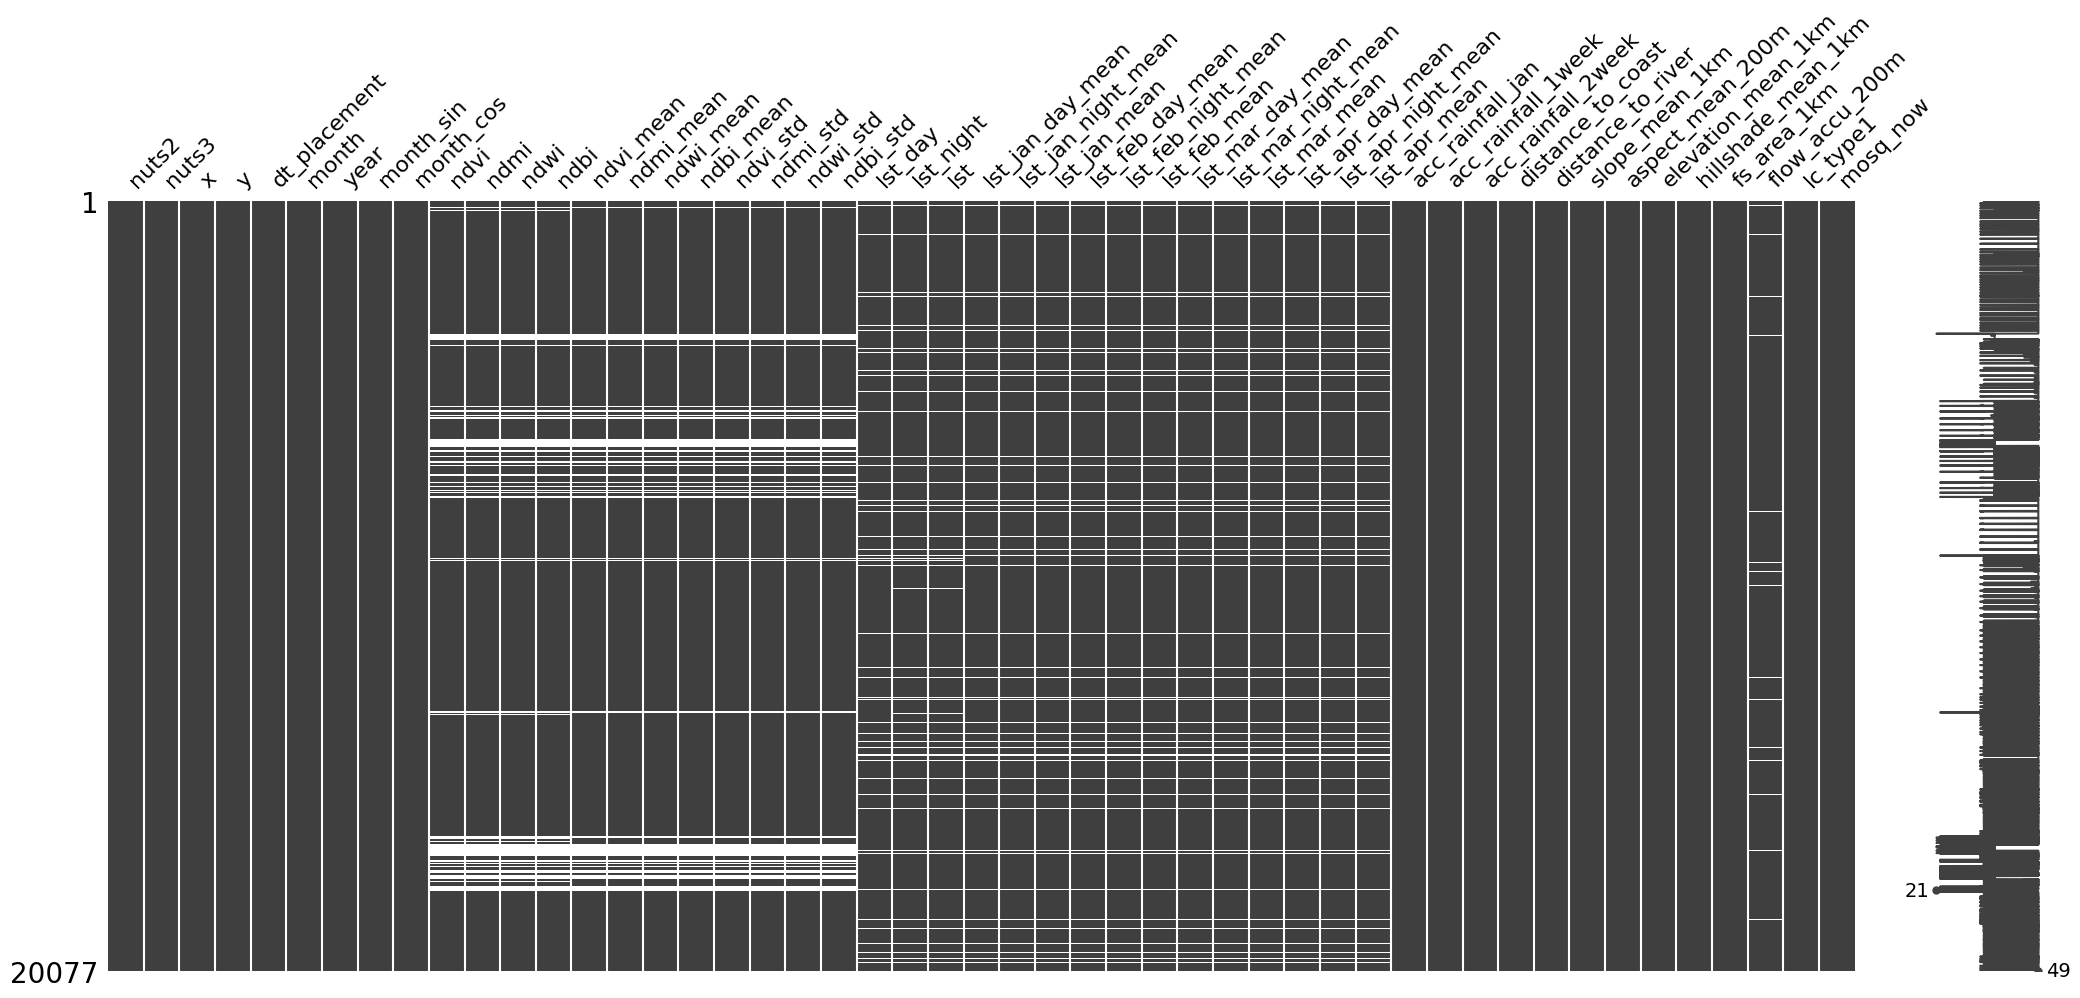

In [39]:
missingno.matrix(dataset)

In [40]:
dataset.to_csv("../data/GR_MSQ_culex_2011-2024_processed.csv", encoding = enc, index = False)